## Research Question
Has there been a discursive shift in EU-funded project justifications from climate-oriented narratives to security- and resilience-oriented narratives?

Research plan:
* Inspect keyword frequency trends over the years (e.g., “climate”, “sustainability” vs. “security”, “resilience”, “strategic autonomy”)
* Topic modeling (BERTopic) to identify thematic clusters per year. Then compare thematic clusters over the years.
* Combining bag-of-words frequency analysis with sentence embedding-based topic modelling via BERTopic. 

To obtain results, I use the project's keywords, titles and descriptions (columns "metadata_title", "metadata_freeKeywords" and "metadata_objective". The data is obtained with the SEDIA-API-FETCHER.)

In [25]:
import numpy as np
import pandas as pd
import json
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from collections import Counter
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import sys
import importlib.util
import subprocess
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN

nltk.download('wordnet')
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")



[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/kimwilmink/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
with open("data/corpus.json", encoding="utf-8") as file:
    corpus_records = json.load(file)

# Keep project metadata in a DataFrame and the corresponding texts in a list.
# Both retain the same row order, which is required by the yearly analyses below.
data = pd.DataFrame(corpus_records)
corpus = data["_combined_text"].fillna("").astype(str).tolist()

print(f"Loaded {len(corpus):,} project texts")

Loaded 58,780 project texts


## Bag of Words

In [27]:
lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    tokens = word_tokenize(text.lower())
    return " ".join(
        lemmatizer.lemmatize(token) 
        for token in tokens
        if token.isalpha()
    )

# Apply before fitting the vectorizers
lemmatized_corpus = [lemmatize_text(doc) for doc in corpus]

In [28]:
#  1. BAG-OF-WORDS (word frequency counts) 
count_vec = CountVectorizer(
    min_df=2,               # ignore terms that appear in fewer than 2 docs
    max_features=500,       # keep only the top 500 terms
)

bow_matrix = count_vec.fit_transform(lemmatized_corpus)
bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    columns=count_vec.get_feature_names_out()
)

# Overall word frequencies across the whole lemmatized corpus
word_freq = bow_df.sum().sort_values(ascending=False)


In [29]:
print(word_freq.head(100))

technology    43022
cell          32417
energy        31131
process       29782
aim           29121
              ...  
property      11387
large         11306
state         11291
industrial    11282
building      11221
Length: 100, dtype: int64


#### Frequency trends by project start year

Raw word counts cannot be compared directly across years because the number of projects and the amount of text differ. Therefore, the graphs below report occurrences per 10,000 words. The analysis uses project start year because it best represents when a project's justification entered the Horizon 2020 portfolio.

The term lists operationalise the two narratives in the research question. They should be treated as an explicit, reproducible dictionary rather than as a complete definition of either discourse. Years with fewer than 100 projects are excluded from the plots because their frequencies are unstable.

In [30]:
# Extract a year from each project's start date.
data["start_year"] = pd.to_datetime(
    data["startdate"], errors="coerce", utc=True
).dt.year

# Dictionary-based operationalisation of the narratives in the research question.
# These forms match the lemmatised corpus produced above.
NARRATIVE_TERMS = {
    "Climate-oriented": [
        "climate", "climate change", "sustainability", "sustainable",
        "environment", "environmental", "renewable", "decarbonisation",
        "decarbonization", "green transition", "climate justice", "global warming",
        "carbon footprint", "carbon neutrality", "carbon neutral"
    ],
    "Security/resilience-oriented": [
        "security", "resilience", "resilient", "defence", "defense",
        "strategic autonomy", "autonomy", "sovereignty", "energy security",
        "preparedness", "vulnerability", "threat", "vulnerable", "self-sufficiency",
        "self-sufficient", "self-reliance", "self-reliant", "supply chain",
        "critical infrastructure", "securitize", "securitization", "geopolitical", "geostrategic"
    ],
}

term_to_narrative = {
    term: narrative
    for narrative, terms in NARRATIVE_TERMS.items()
    for term in terms
}

# Use a dedicated vectorizer so theoretically relevant terms are not removed by
# the max_features=500 setting used for the exploratory word-frequency table.
trend_vectorizer = CountVectorizer(
    vocabulary=list(term_to_narrative),
    ngram_range=(1, 2),
)
trend_matrix = trend_vectorizer.fit_transform(lemmatized_corpus)

term_counts = pd.DataFrame(
    trend_matrix.toarray(),
    columns=trend_vectorizer.get_feature_names_out(),
    index=data.index,
)

# Denominator used to compare years with different amounts of text.
data["token_count"] = [len(document.split()) for document in lemmatized_corpus]
term_counts["start_year"] = data["start_year"]
term_counts["token_count"] = data["token_count"]

In [34]:
# Aggregate term counts and denominators by year.
terms = list(term_to_narrative)
annual_counts = term_counts.groupby("start_year")[terms].sum()
annual_tokens = term_counts.groupby("start_year")["token_count"].sum()
annual_projects = data.groupby("start_year").size()

# Occurrences per 10,000 words.
annual_frequency = annual_counts.div(annual_tokens, axis=0) * 10_000
term_frequency = annual_frequency.copy()

# Avoid drawing conclusions from years represented by only a handful of projects.
MIN_PROJECTS_PER_YEAR = 100
included_years = annual_projects[annual_projects >= MIN_PROJECTS_PER_YEAR].index
annual_frequency = annual_frequency.loc[included_years]

year_summary = pd.DataFrame({
    "projects": annual_projects.loc[included_years],
    "analysed_words": annual_tokens.loc[included_years],
})
display(year_summary)

,projects,analysed_words
start_year,,
2014,882,145167
2015,4849,821566
2016,5142,874624
2017,4810,825552
2018,5324,913844
2019,5493,944448
2020,4588,796281
2021,3715,643850
2022,5149,881236


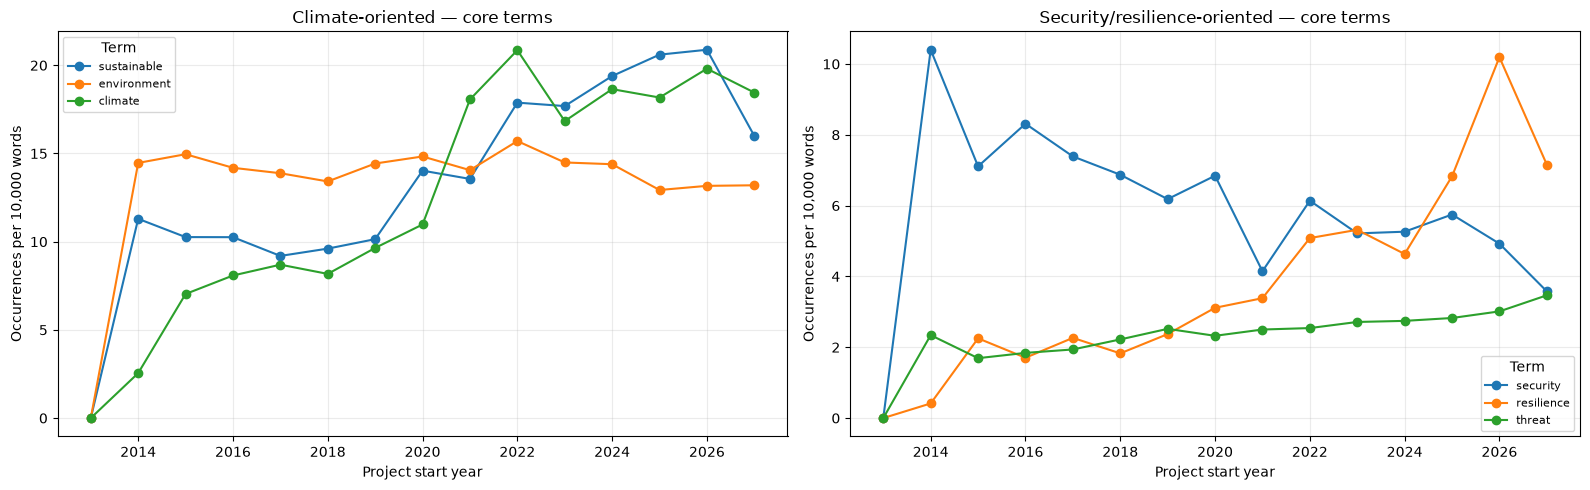

In [35]:
# Inspect a compact set of core terms for each narrative so the plot stays readable.
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)

for ax, (narrative, narrative_terms) in zip(axes, NARRATIVE_TERMS.items()):
    top_terms = (
        term_frequency[narrative_terms]
        .mean()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )
    term_frequency[top_terms].plot(ax=ax, marker="o")
    ax.set_title(f"{narrative} — core terms")
    ax.set_xlabel("Project start year")
    ax.set_ylabel("Occurrences per 10,000 words")
    ax.grid(alpha=0.25)
    ax.legend(title="Term", fontsize=8)

plt.tight_layout()
plt.show()


#### Robustness check: share of projects mentioning each narrative

Repeated use of a word in a small number of projects could dominate token frequency. The following measure instead counts each project at most once per narrative and reports the percentage of projects that mention at least one dictionary term.

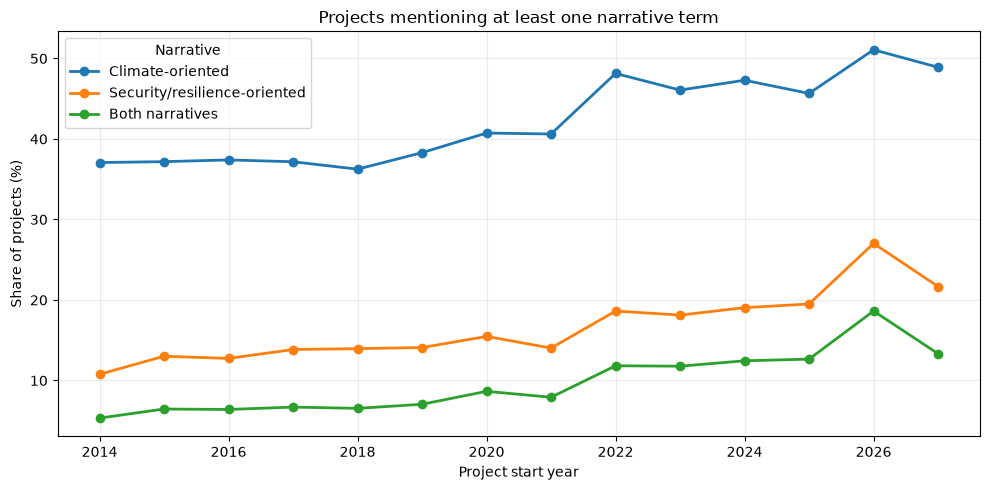

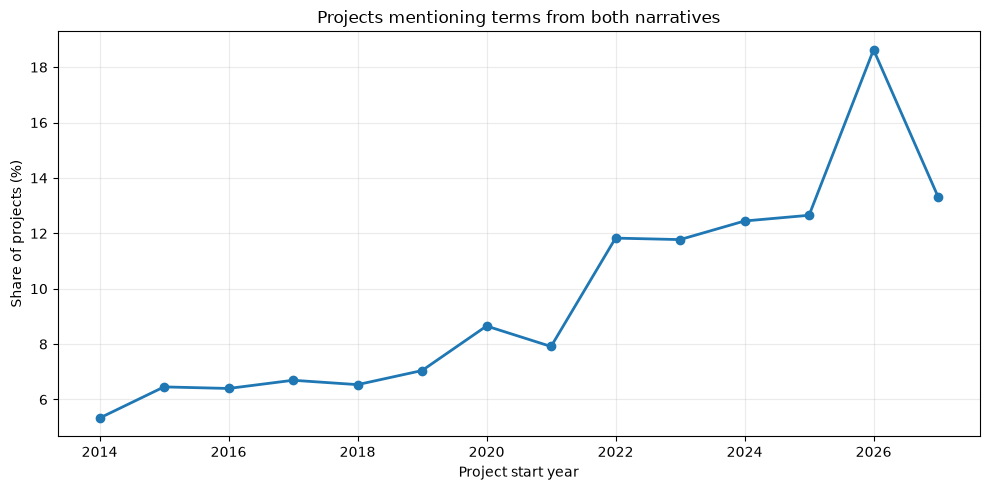

,Climate-oriented,Security/resilience-oriented,Both narratives
start_year,,,
2014,37.07,10.77,5.33
2015,37.18,13.01,6.45
2016,37.40,12.74,6.40
2017,37.17,13.85,6.69
2018,36.25,13.96,6.54
2019,38.30,14.09,7.05
2020,40.74,15.48,8.65
2021,40.62,14.02,7.91
2022,48.15,18.62,11.83


In [36]:
project_mentions = pd.DataFrame(index=data.index)
project_mentions["start_year"] = data["start_year"]

for narrative, terms in NARRATIVE_TERMS.items():
    project_mentions[narrative] = term_counts[terms].sum(axis=1).gt(0)

project_mentions["Both narratives"] = project_mentions[list(NARRATIVE_TERMS)].all(axis=1)

annual_project_share = (
    project_mentions.groupby("start_year")[list(NARRATIVE_TERMS) + ["Both narratives"]]
    .mean()
    .mul(100)
    .loc[included_years]
)

ax = annual_project_share.plot(figsize=(10, 5), marker="o", linewidth=2)
ax.set(
    title="Projects mentioning at least one narrative term",
    xlabel="Project start year",
    ylabel="Share of projects (%)",
)
ax.grid(alpha=0.25)
ax.legend(title="Narrative")
plt.tight_layout()
plt.show()

ax = (
    project_mentions.groupby("start_year")["Both narratives"]
    .mean()
    .mul(100)
    .loc[included_years]
    .plot(figsize=(10, 5), marker="o", linewidth=2)
)
ax.set(
    title="Projects mentioning terms from both narratives",
    xlabel="Project start year",
    ylabel="Share of projects (%)",
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(annual_project_share.round(2))


# Narrowing down the dataset
The above analysis was performed on the entire corpus of extracted projects of the Horizon2020 and Horizon Europe programmes. Since this thesis only focusses on climate-related projects, the following Bag-of-Words analysis will be performed on the subset of the corpus that relates to climate change.

In [41]:
climate_terms = NARRATIVE_TERMS["Climate-oriented"]
available_climate_terms = [t for t in climate_terms if t in term_counts.columns]
missing_climate_terms = [t for t in climate_terms if t not in term_counts.columns]
if missing_climate_terms:
    print("WARNING: The following climate terms are missing from term_counts and will be ignored:")
    print(missing_climate_terms)

if not available_climate_terms:
    raise RuntimeError("No climate terms are available in term_counts. Check the NARRATIVE_TERMS vocabulary and vectorizer settings.")

climate_mask = term_counts[available_climate_terms].sum(axis=1) > 0
climate_data = data.loc[climate_mask].copy()
climate_corpus = climate_data["_combined_text"].fillna("").astype(str).tolist()

print(f"Climate-related subset size: {len(climate_data):,} projects")
print(f"Selected {len(climate_data) / len(data) * 100:.1f}% of the full corpus")

# Keep the climate subset for the topic modeling stage.
# Later cells can use `climate_data` and `climate_corpus` instead of the full corpus.

Climate-related subset size: 24,676 projects
Selected 42.0% of the full corpus


Climate subset word frequency (top 50):


energy           21851
technology       21162
process          14945
sustainable      14428
environment      14390
european         14191
material         13731
climate          13563
impact           12716
environmental    12522
aim              12223
change           12111
innovation       11692
market           10423
develop          10360
eu               10235
europe            9879
industry          9785
design            9673
production        9619
innovative        9342
knowledge         9169
also              9054
application       9037
tool              8912
challenge         8798
high              8769
novel             8473
management        8442
service           8303
global            8303
support           8257
policy            8247
model             8203
water             8132
potential         7972
cell              7902
science           7867
health            7815
objective         7763
product           7762
social            7743
key               7707
strategy   

,projects,analysed_words
start_year,,
2014,327,56610
2015,1803,311935
2016,1923,334433
2017,1788,315072
2018,1930,339718
2019,2104,370020
2020,1869,330961
2021,1509,265026
2022,2479,433226


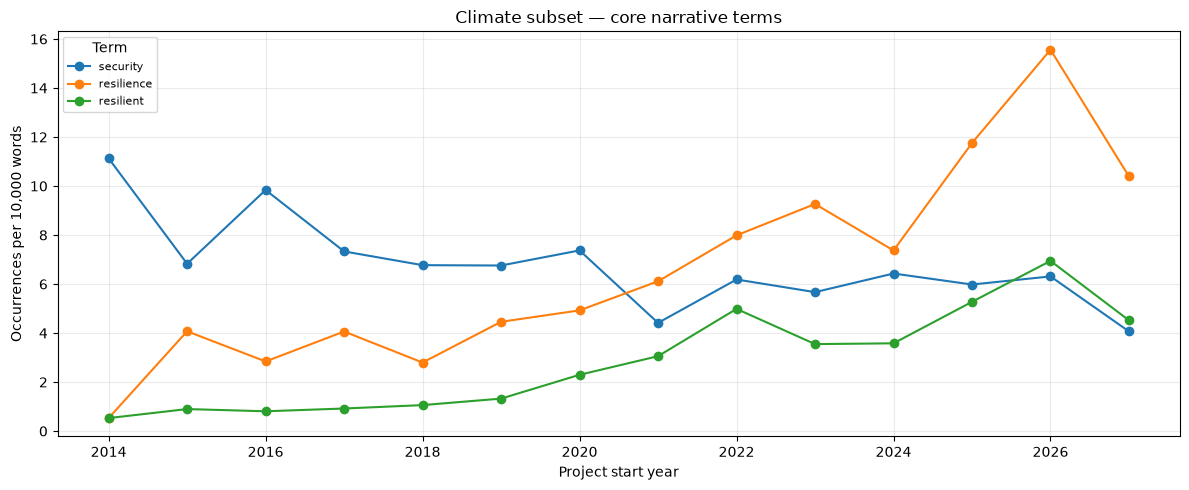

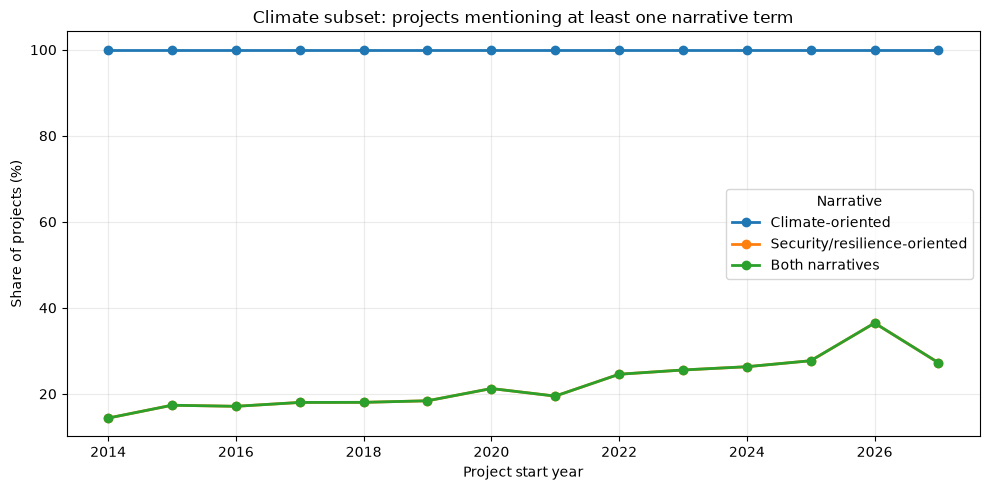

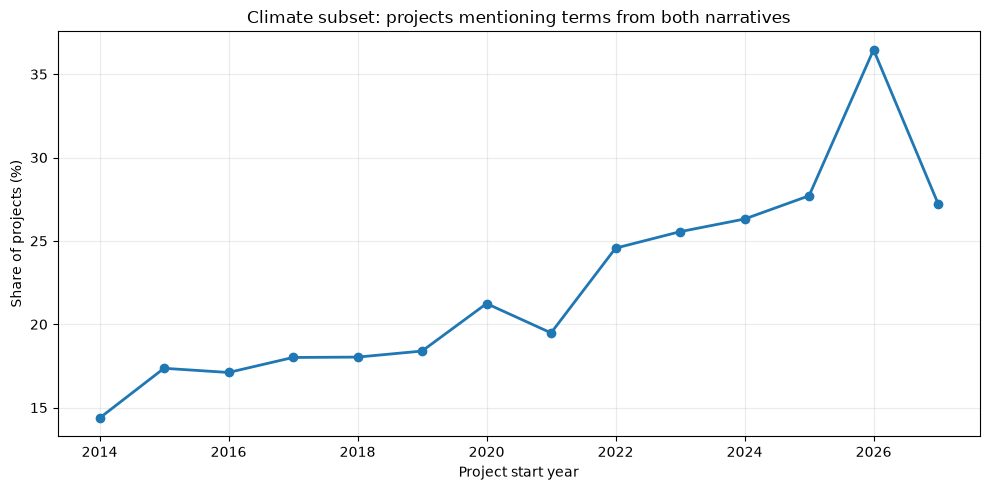

,Climate-oriented,Security/resilience-oriented,Both narratives
start_year,,,
2014,100.0,14.37,14.37
2015,100.0,17.36,17.36
2016,100.0,17.11,17.11
2017,100.0,18.01,18.01
2018,100.0,18.03,18.03
2019,100.0,18.39,18.39
2020,100.0,21.24,21.24
2021,100.0,19.48,19.48
2022,100.0,24.57,24.57


In [42]:
# Repeat the bag-of-words analysis on the climate subset only.
climate_lemmatized_corpus = [lemmatize_text(doc) for doc in climate_corpus]

climate_count_vec = CountVectorizer(
    min_df=2,
    max_features=500,
)
climate_bow_matrix = climate_count_vec.fit_transform(climate_lemmatized_corpus)
climate_bow_df = pd.DataFrame(
    climate_bow_matrix.toarray(),
    columns=climate_count_vec.get_feature_names_out(),
)
climate_word_freq = climate_bow_df.sum().sort_values(ascending=False)

print("Climate subset word frequency (top 50):")
display(climate_word_freq.head(50))

climate_trend_matrix = trend_vectorizer.transform(climate_lemmatized_corpus)
climate_term_counts = pd.DataFrame(
    climate_trend_matrix.toarray(),
    columns=trend_vectorizer.get_feature_names_out(),
    index=climate_data.index,
)
climate_data["token_count"] = [len(document.split()) for document in climate_lemmatized_corpus]
climate_term_counts["start_year"] = climate_data["start_year"]
climate_term_counts["token_count"] = climate_data["token_count"]

available_climate_terms = [t for t in terms if t in climate_term_counts.columns]
missing_climate_terms = [t for t in terms if t not in climate_term_counts.columns]
if missing_climate_terms:
    print("WARNING: The following narrative terms are missing from climate_term_counts and will be ignored in the climate subset analysis:")
    print(missing_climate_terms)
if not available_climate_terms:
    raise RuntimeError("No narrative terms are available in climate_term_counts. Check the NARRATIVE_TERMS vocabulary and vectorizer settings.")

climate_annual_counts = climate_term_counts.groupby("start_year")[available_climate_terms].sum()
climate_annual_tokens = climate_term_counts.groupby("start_year")["token_count"].sum()
climate_annual_projects = climate_data.groupby("start_year").size()
climate_annual_frequency = climate_annual_counts.div(climate_annual_tokens, axis=0) * 10_000
climate_included_years = climate_annual_projects[climate_annual_projects >= MIN_PROJECTS_PER_YEAR].index
climate_annual_frequency = climate_annual_frequency.loc[climate_included_years]

climate_year_summary = pd.DataFrame({
    "projects": climate_annual_projects.loc[climate_included_years],
    "analysed_words": climate_annual_tokens.loc[climate_included_years],
})
display(climate_year_summary)

climate_term_frequency = climate_annual_frequency.copy()

fig, ax = plt.subplots(figsize=(12, 5))
for narrative, narrative_terms in NARRATIVE_TERMS.items():
    available_narrative_terms = [t for t in narrative_terms if t in climate_term_frequency.columns]
    if not available_narrative_terms:
        continue
    top_terms = (
        climate_term_frequency[available_narrative_terms]
        .mean()
        .sort_values(ascending=False)
        .head(3)
        .index.tolist()
    )
    climate_term_frequency[top_terms].plot(ax=ax, marker="o")

ax.set_title("Climate subset — core narrative terms")
ax.set_xlabel("Project start year")
ax.set_ylabel("Occurrences per 10,000 words")
ax.grid(alpha=0.25)
ax.legend(title="Term", fontsize=8)
plt.tight_layout()
plt.show()

climate_project_mentions = pd.DataFrame(index=climate_data.index)
climate_project_mentions["start_year"] = climate_data["start_year"]
for narrative, narrative_terms in NARRATIVE_TERMS.items():
    available_narrative_terms = [t for t in narrative_terms if t in climate_term_counts.columns]
    if not available_narrative_terms:
        climate_project_mentions[narrative] = False
    else:
        climate_project_mentions[narrative] = climate_term_counts[available_narrative_terms].sum(axis=1).gt(0)
climate_project_mentions["Both narratives"] = climate_project_mentions[list(NARRATIVE_TERMS)].all(axis=1)

climate_annual_project_share = (
    climate_project_mentions.groupby("start_year")[list(NARRATIVE_TERMS) + ["Both narratives"]]
    .mean()
    .mul(100)
    .loc[climate_included_years]
)

ax = climate_annual_project_share.plot(figsize=(10, 5), marker="o", linewidth=2)
ax.set(
    title="Climate subset: projects mentioning at least one narrative term",
    xlabel="Project start year",
    ylabel="Share of projects (%)",
)
ax.grid(alpha=0.25)
ax.legend(title="Narrative")
plt.tight_layout()
plt.show()

ax = (
    climate_project_mentions.groupby("start_year")["Both narratives"]
    .mean()
    .mul(100)
    .loc[climate_included_years]
    .plot(figsize=(10, 5), marker="o", linewidth=2)
)
ax.set(
    title="Climate subset: projects mentioning terms from both narratives",
    xlabel="Project start year",
    ylabel="Share of projects (%)",
)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

display(climate_annual_project_share.round(2))


## BERTopic 

### BERTopic set-up and sample validation

This section tests BERTopic on a small random subset of documents before scaling to the full corpus.

In [3]:
required_packages = [
    "bertopic",
    "sentence-transformers",
    "umap-learn",
    "hdbscan",
]
missing = [pkg for pkg in required_packages if importlib.util.find_spec(pkg) is None]
if missing:
    print("Installing missing BERTopic dependencies:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All BERTopic dependencies are already installed.")

Installing missing BERTopic dependencies: ['sentence-transformers', 'umap-learn']


In [1]:
corpus_raw = climate_corpus
print(f"Climate subset size: {len(corpus_raw):,} documents")

sample_size = min(500, len(corpus_raw))  # smaller test sample for faster validation
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(corpus_raw), size=sample_size, replace=False)
sample_texts = [corpus_raw[i] for i in sample_idx]

print(f"Using sample_size={sample_size} for the initial BERTopic test on the climate subset")

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

sample_topic_model = BERTopic(
    language="english",
    embedding_model=embedding_model,
    umap_model=UMAP(
        n_neighbors=20,
        n_components=5,
        metric="cosine",
        random_state=42,
    ),
    hdbscan_model=HDBSCAN(
        min_cluster_size=5,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True,
    ),
    min_topic_size=5,
    verbose=True,
)

sample_topics, sample_probs = sample_topic_model.fit_transform(sample_texts)
print(f"Sample BERTopic test finished. Extracted {len(sample_topic_model.get_topic_info()) - 1} valid topics.")

NameError: name 'climate_corpus' is not defined

In [21]:
# Review the sample topics and document distribution.
topic_info = sample_topic_model.get_topic_info()
display(topic_info.head(20))

topic_counts = pd.Series(sample_topics).value_counts().rename_axis("Topic").reset_index(name="Document count")
display(topic_counts.head(10))

print("Example topic keywords:")
for topic_num in topic_info[topic_info.Topic >= 0]["Topic"].head(5):
    print(f"\nTopic {topic_num}:")
    print(sample_topic_model.get_topic(topic_num))

,Topic,Count,Name,Representation,Representative_Docs
0,-1,178,-1_european_innovation_technology_develop,"[european, innovation, technology, develop, di...",[twinning build industrial ecosystem around co...
1,0,35,0_brain_language_activity_speech,"[brain, language, activity, speech, neural, se...",[peptidergic neuromodulation sensory represent...
2,1,29,1_cultural_social_history_people,"[cultural, social, history, people, science, v...",[values across space time discussion values pe...
3,2,26,2_cancer_cells_cell_states,"[cancer, cells, cell, states, drug, tumor, cel...",[giantleaps tumorigenesis dissecting saltatory...
4,3,26,3_manufacturing_design_materials_high,"[manufacturing, design, materials, high, produ...",[additive manufacturing amorphous metals soft ...
5,4,22,4_marine_climate_ecosystems_change,"[marine, climate, ecosystems, change, restorat...",[unraveling tipping dynamics marine biogeochem...
6,5,21,5_transport_road_maintenance_mobility,"[transport, road, maintenance, mobility, parki...",[energy service clean transportation road tran...
7,6,21,6_catalysts_battery_energy_materials,"[catalysts, battery, energy, materials, batter...",[safe prelithiated high energy density batteri...
8,7,18,7_clinical_device_tissue_iodine,"[clinical, device, tissue, iodine, drug, healt...",[novel embryo transfer technology improve preg...
9,8,16,8_waste_water_technology_plastic,"[waste, water, technology, plastic, energy, co...",[low carbon footprint ecoinnovative uv water d...


,Topic,Document count
0,-1,178
1,0,35
2,1,29
3,2,26
4,3,26
5,4,22
6,5,21
7,6,21
8,7,18
9,8,16


Example topic keywords:

Topic 0:
[('brain', np.float64(0.05168196354813652)), ('language', np.float64(0.027162767162862866)), ('activity', np.float64(0.021360248475921224)), ('speech', np.float64(0.021152345818053628)), ('neural', np.float64(0.020322393266151678)), ('sensory', np.float64(0.01832566138964284)), ('neuronal', np.float64(0.0169218766544429)), ('neurons', np.float64(0.016075782821720758)), ('functional', np.float64(0.01577439901500834)), ('disorders', np.float64(0.015641443179322752))]

Topic 1:
[('cultural', np.float64(0.0419918709826234)), ('social', np.float64(0.02941484645037723)), ('history', np.float64(0.02587713776749687)), ('people', np.float64(0.02347587884141794)), ('science', np.float64(0.02334008398992338)), ('values', np.float64(0.021856818752296208)), ('heritage', np.float64(0.01971883169527894)), ('rural', np.float64(0.01801005502492578)), ('migration', np.float64(0.017412604424250036)), ('european', np.float64(0.01687760472182949))]

Topic 2:
[('cancer', np

In [23]:
# Visualize the top sample topics.
sample_topic_model.visualize_barchart(top_n_topics=20)

### Fitting BERTopic on the full corpus after sample succeeds

In [ ]:
# full_topic_model = BERTopic(
#     language="english",
#     embedding_model=embedding_model,
#     umap_model=UMAP(
#         n_neighbors=15,
#         n_components=5,
#         metric="cosine",
#         random_state=42,
#     ),
#     hdbscan_model=HDBSCAN(
#         min_cluster_size=15,
#         metric="euclidean",
#         cluster_selection_method="eom",
#         prediction_data=True,
#     ),
#     min_topic_size=15,
#     verbose=True,
# )
#
# full_topics, full_probs = full_topic_model.fit_transform(corpus_raw)
#
# full_topic_info = full_topic_model.get_topic_info()
# display(full_topic_info.head(20))



### Year-by-year BERTopic comparison

This section compares topic distributions across years using the full BERTopic model results. It assumes `full_topic_model` and `full_topics` are available after running the full corpus fit.

In [ ]:
if "full_topic_model" not in globals() or "full_topics" not in globals():
    raise RuntimeError(
        "Run the full BERTopic fit cell first to create `full_topic_model` and `full_topics` before executing this comparison section."
    )

if "full_topic_info" not in globals():
    full_topic_info = full_topic_model.get_topic_info()

# Combine year metadata with assigned topics.
bertopic_year_df = pd.DataFrame({
    "start_year": data["start_year"],
    "topic": full_topics,
})
bertopic_year_df = bertopic_year_df[bertopic_year_df["start_year"].notna()].copy()
bertopic_year_df["start_year"] = bertopic_year_df["start_year"].astype(int)

MIN_DOCS_PER_YEAR = 30
valid_years = (
    bertopic_year_df.groupby("start_year").size().loc[lambda s: s >= MIN_DOCS_PER_YEAR].index
)
bertopic_year_df = bertopic_year_df[bertopic_year_df["start_year"].isin(valid_years)]

if bertopic_year_df.empty:
    raise RuntimeError("No years remain after filtering for minimum document count. Lower MIN_DOCS_PER_YEAR or inspect the data.")

year_counts = bertopic_year_df.groupby("start_year").size().rename("year_count")
topic_year_counts = (
    bertopic_year_df.groupby(["start_year", "topic"]).size().rename("count").reset_index()
)
topic_year_counts = topic_year_counts.merge(year_counts, on="start_year")
topic_year_counts["share_pct"] = topic_year_counts["count"] / topic_year_counts["year_count"] * 100

topic_name_map = dict(zip(full_topic_info.Topic, full_topic_info.Name))
topic_year_counts["topic_name"] = topic_year_counts["topic"].map(topic_name_map).fillna("Other")

# Show the top topics for each year.
top_by_year = (
    topic_year_counts.sort_values(["start_year", "share_pct"], ascending=[True, False])
    .groupby("start_year")
    .head(5)
    .reset_index(drop=True)
)

display(top_by_year[["start_year", "topic", "topic_name", "count", "year_count", "share_pct"]].round({"share_pct": 2}))

In [ ]:
# Visualize the strongest topics across years.
TOP_N_TOPICS = 12
popular_topics = (
    topic_year_counts.groupby("topic")
    ["share_pct"].mean()
    .nlargest(TOP_N_TOPICS)
    .index
)
plot_df = topic_year_counts[topic_year_counts["topic"].isin(popular_topics)].copy()
plot_df["topic_label"] = plot_df.apply(
    lambda row: f"{row.topic} — {row.topic_name}", axis=1
)

fig = px.bar(
    plot_df,
    x="start_year",
    y="share_pct",
    color="topic_label",
    title=f"Top {TOP_N_TOPICS} BERTopic clusters by year",
    labels={"share_pct": "Share of documents (%)", "start_year": "Project start year"},
    category_orders={"start_year": sorted(valid_years)},
)
fig.update_layout(barmode="stack", legend_title_text="Topic")
fig.show()

In [ ]:
# Create a pivot for year-topic shares and display the most stable topics over time.
heatmap_df = (
    topic_year_counts[topic_year_counts["topic"].isin(popular_topics)]
    .pivot(index="topic", columns="start_year", values="share_pct")
    .fillna(0)
)
heatmap_df.index = [f"{topic} — {topic_name_map.get(topic, 'Other')}" for topic in heatmap_df.index]

fig, ax = plt.subplots(figsize=(14, max(5, 0.4 * len(heatmap_df.index))))
im = ax.imshow(heatmap_df, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)
ax.set_xlabel("Project start year")
ax.set_ylabel("BERTopic cluster")
ax.set_title("Yearly share of top BERTopic clusters")
fig.colorbar(im, ax=ax, label="Share of documents (%)")
plt.tight_layout()
plt.show()

#### Topic trends across years

This line plot shows how the share of the top BERTopic clusters changes year by year.

In [ ]:
line_df = plot_df.copy().sort_values(["topic", "start_year"])
fig = px.line(
    line_df,
    x="start_year",
    y="share_pct",
    color="topic_label",
    title=f"Yearly evolution of top {TOP_N_TOPICS} BERTopic clusters",
    labels={"share_pct": "Share of documents (%)", "start_year": "Project start year"},
    category_orders={"start_year": sorted(valid_years)},
)
fig.update_traces(mode="lines+markers")
fig.update_layout(legend_title_text="Topic", hovermode="x unified")
fig.show()

### Representative documents per topic and year

The next cell extracts a few documents for the top topics in each year. This helps interpret the topic labels and check whether the same topic themes persist across years.

In [ ]:
EXAMPLE_DOCS_PER_TOPIC = 2
representative_docs = []

for year in sorted(valid_years):
    top_topics = (
        topic_year_counts[topic_year_counts["start_year"] == year]
        .sort_values("share_pct", ascending=False)
        .head(3)["topic"]
        .tolist()
    )
    for topic in top_topics:
        subset = data.loc[(data["start_year"] == year) & (pd.Series(full_topics) == topic), "_combined_text"]
        sample_texts = subset.dropna().astype(str).tolist()[:EXAMPLE_DOCS_PER_TOPIC]
        representative_docs.append({
            "year": year,
            "topic": topic,
            "topic_name": topic_name_map.get(topic, "Other"),
            "examples": sample_texts,
        })

for entry in representative_docs:
    print(f"Year {entry['year']} — Topic {entry['topic']} — {entry['topic_name']}")
    for i, example in enumerate(entry["examples"], 1):
        print(f"  Example {i}: {example[:320].replace('\n', ' ')}")
    print("\n" + "-" * 80 + "\n")